# Step 2: Exploratory Data Analysis (EDA)
Understand patterns in the ecommerce dataset through charts and summary statistics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
df = pd.read_csv('../ecommerce_orders_cleaned.csv', parse_dates=['order_date'])
print('Loaded:', df.shape)
df.head()

Loaded: (500, 19)


,order_id,customer_id,customer_age,customer_gender,city,order_date,product,category,quantity,unit_price,discount_pct,discount_amount,revenue,payment_method,order_status,month,year,day_of_week,age_group
0,ORD00001,CUST0091,50.0,Other,Hyderabad,2023-12-25,T-Shirt,Clothing,4,538.49,10.0,215.40,1938.56,Debit Card,Delivered,12,2023,Monday,46-60
1,ORD00002,CUST0009,51.0,Male,Delhi,2023-10-13,Backpack,Accessories,3,1550.96,10.0,465.29,4187.59,Cash on Delivery,Delivered,10,2023,Friday,46-60
2,ORD00003,CUST0125,20.0,Female,Ahmedabad,2023-09-25,Running Shoes,Footwear,1,5713.41,5.0,285.67,5427.74,Cash on Delivery,Returned,9,2023,Monday,18-25
3,ORD00004,CUST0016,56.0,Male,Hyderabad,2023-11-18,Laptop,Electronics,1,49336.10,15.0,7400.41,41935.69,Cash on Delivery,Returned,11,2023,Saturday,46-60
4,ORD00005,CUST0030,55.0,Other,Kolkata,2023-02-15,Backpack,Accessories,1,3207.56,25.0,801.89,2405.67,Net Banking,Delivered,2,2023,Wednesday,46-60


## 1. Revenue Overview

In [2]:
print('Total Revenue: ₹', round(df['revenue'].sum(), 2))
print('Average Order Value: ₹', round(df['revenue'].mean(), 2))
print('Median Order Value: ₹', round(df['revenue'].median(), 2))
print('Max Order Value: ₹', round(df['revenue'].max(), 2))
print('Total Orders:', len(df))

Total Revenue: ₹ 7286896.26
Average Order Value: ₹ 14573.79
Median Order Value: ₹ 3796.05
Max Order Value: ₹ 269103.7
Total Orders: 500


## 2. Monthly Revenue Trend

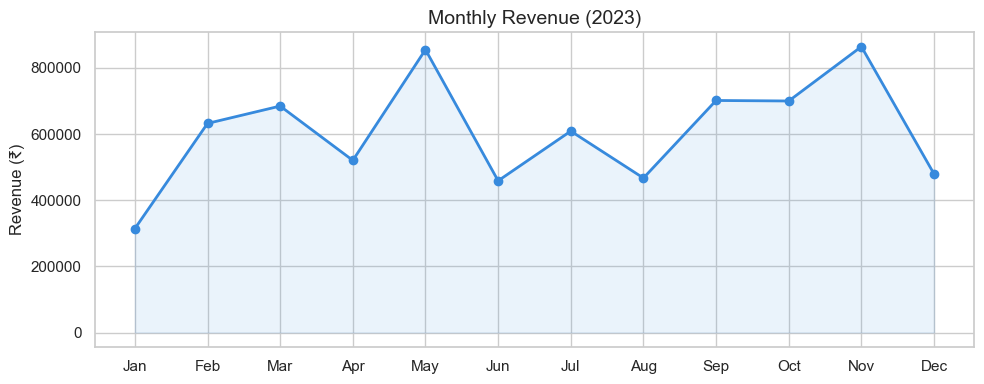

In [3]:
monthly = df.groupby('month')['revenue'].sum().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['month_name'] = monthly['month'].apply(lambda x: month_names[x-1])

plt.figure(figsize=(10, 4))
plt.plot(monthly['month_name'], monthly['revenue'], marker='o', color='#378ADD', linewidth=2)
plt.fill_between(monthly['month_name'], monthly['revenue'], alpha=0.1, color='#378ADD')
plt.title('Monthly Revenue (2023)', fontsize=14)
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Revenue by Category

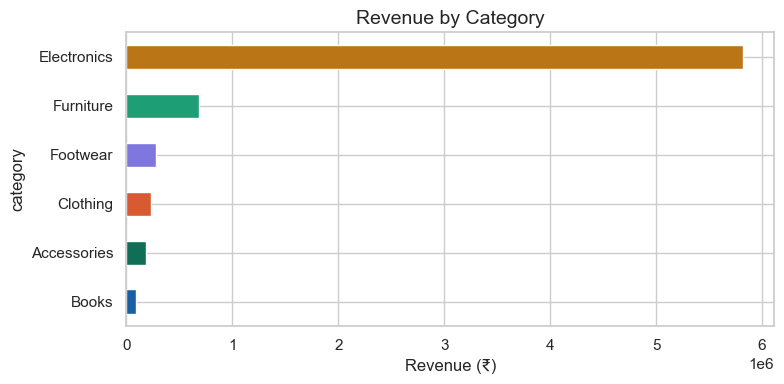

category
Electronics    5822103.86
Furniture       684780.74
Footwear        280777.17
Clothing        233060.97
Accessories     180661.74
Books            85511.78
Name: revenue, dtype: float64


In [4]:
cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=True)

colors = ['#185FA5','#0F6E56','#D85A30','#7F77DD','#1D9E75','#BA7517']
plt.figure(figsize=(8, 4))
cat_rev.plot(kind='barh', color=colors)
plt.title('Revenue by Category', fontsize=14)
plt.xlabel('Revenue (₹)')
plt.tight_layout()
plt.show()

print(cat_rev.sort_values(ascending=False))

## 4. Order Status Distribution

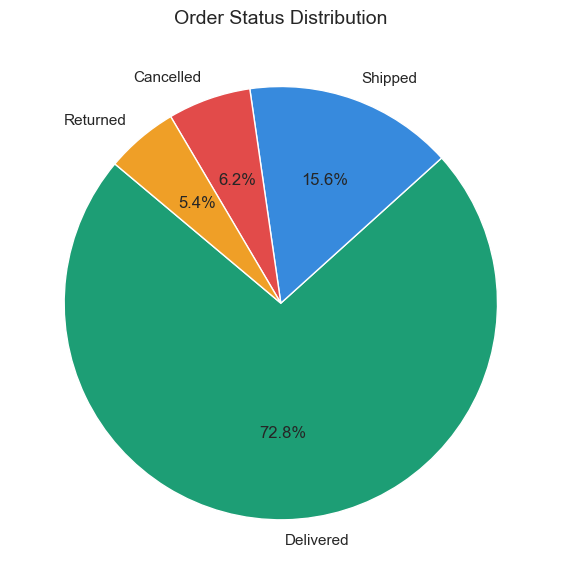

In [5]:
status_counts = df['order_status'].value_counts()
colors = ['#1D9E75','#378ADD','#E24B4A','#EF9F27']

plt.figure(figsize=(6, 6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=140)
plt.title('Order Status Distribution', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Top Cities by Revenue

C:\Users\vadla\AppData\Local\Temp\ipykernel_21824\1865146462.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_rev.values, y=city_rev.index, palette='Blues_r')


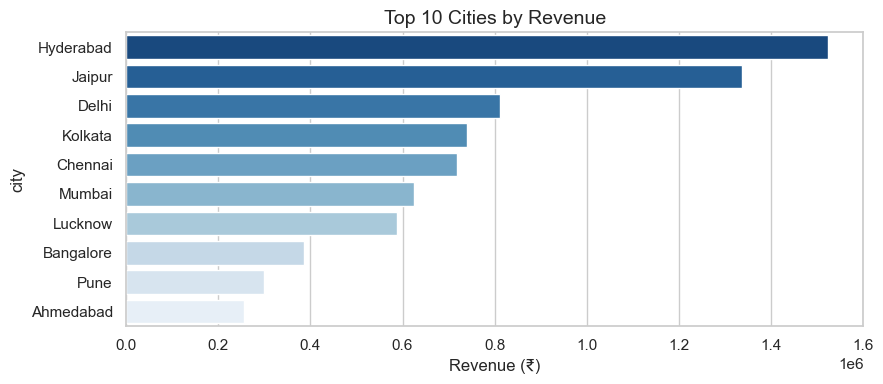

In [6]:
city_rev = df.groupby('city')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 4))
sns.barplot(x=city_rev.values, y=city_rev.index, palette='Blues_r')
plt.title('Top 10 Cities by Revenue', fontsize=14)
plt.xlabel('Revenue (₹)')
plt.tight_layout()
plt.show()

## 6. Payment Methods

C:\Users\vadla\AppData\Local\Temp\ipykernel_21824\3561851341.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pay_counts.index, y=pay_counts.values,


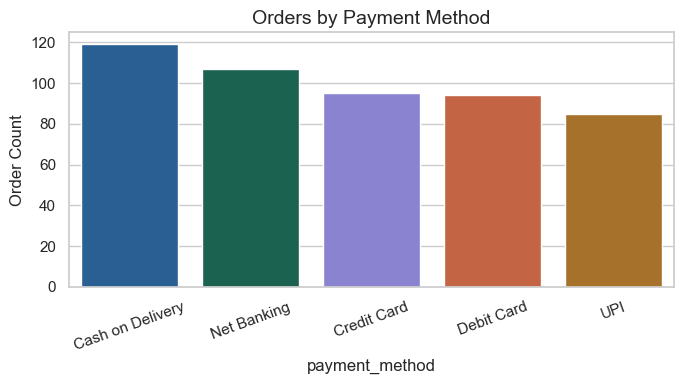

In [7]:
pay_counts = df['payment_method'].value_counts()
plt.figure(figsize=(7, 4))
sns.barplot(x=pay_counts.index, y=pay_counts.values,
            palette=['#185FA5','#0F6E56','#7F77DD','#D85A30','#BA7517'])
plt.title('Orders by Payment Method', fontsize=14)
plt.ylabel('Order Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 7. Customer Age Distribution

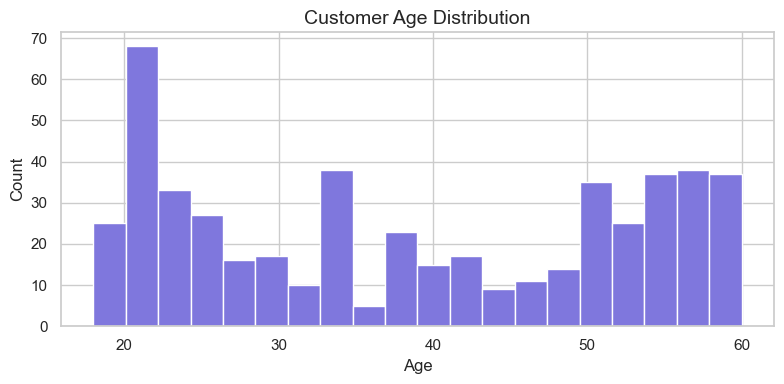

Average customer age: 38.6


In [8]:
plt.figure(figsize=(8, 4))
df['customer_age'].hist(bins=20, color='#7F77DD', edgecolor='white')
plt.title('Customer Age Distribution', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print('Average customer age:', round(df['customer_age'].mean(), 1))